<a href="https://colab.research.google.com/github/bidallei/MIAAD-UACJ/blob/main/Hernandez_Alvaro_Mnist.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Cálculo de parámetros de la red del ejemplo compartido**

* Asignatura: Redes Neuronales Profundas
* Profesor: Dr. José David Díaz Román
* Alumno: **Álvaro Hernández Jarquín**
* Matrícula: 263150
* 16 de febrero de 2026




# **Objetivo**

Dado el ejemplo de la arquitectura de la CNN compartida en el archivo "Clasificación MNIST.py":

* Determinar la cantidad de parámetros entrenables de dicha red.
  * Desglosarlos por cada capa y mostrar los cálculos. Incluir las capas densas.
* Determinar la cantidad de operaciones de multiplicación que se realizan en la primera y segunda capa convolucional de la red del ejemplo. Tome en cuenta que la primera capa recibe una entrada de tamaño 28x28 en escala de grices (un solo canal).
* Asumiendo que ahora la red tiene como entrada una imagen del mismo tamaño (28x28) pero esta vez en formato RGB (tres canales), determinar la cantidad de parámetros entrenables de red completa (desglosados por capas). Compare con los parámetros de la red que recibe la imagen de un solo canal.
* Del mismo modo, calcule la cantidad de operaciones de la primera y segunda capa convolucional de la red, asumiendo que esta recibe una imágen RGB de tamaño 28x28. Compare con las operaciones de multiplicación de la red que recibe la imagen de un solo canal. <br>

Apoyarse en la explicación presentada en las diapositivas 10 a 24 del archivo compartido: *Unidad 2. Redes neuronales convolucionales.pptx*

In [ ]:
# Librerías y funciones a utilizar

import matplotlib.pyplot as plt
import numpy as np
import keras
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.utils import to_categorical

In [ ]:
print(f"Versión de Keras: {keras.__version__}")
print(f"Versión de TensorFlow: {tf.__version__}")

Versión de Keras: 3.10.0
Versión de TensorFlow: 2.19.0


In [ ]:
# Cargar datos
(X_train, y_train), (X_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


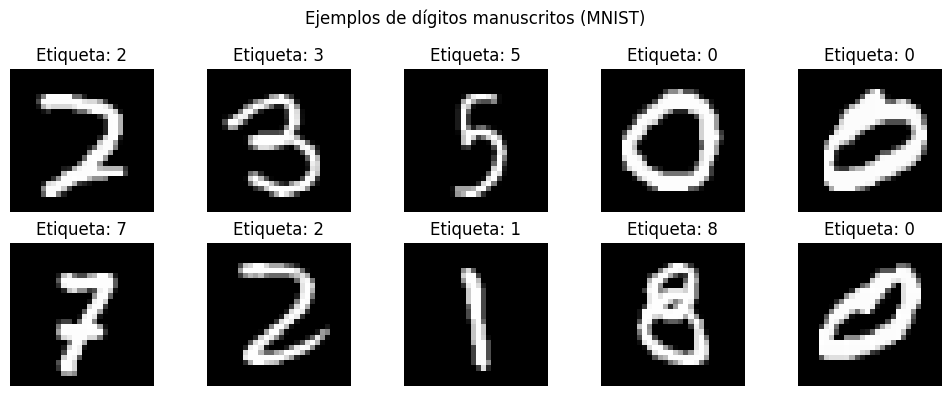

In [ ]:
# Visualizar algunos ejemplos
ind = np.random.permutation(len(X_train)) #elegir índices aleatorios
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[ind[i]], cmap='gray')
    plt.title(f"Etiqueta: {y_train[ind[i]]}")
    plt.axis('off')
plt.suptitle("Ejemplos de dígitos manuscritos (MNIST)")
plt.tight_layout()
plt.show()

In [ ]:
# Preprocesamiento
# Añadir dimensión del canal al final y normalizamos entre 0 y 1
X_train = np.expand_dims(X_train, axis=-1)/ 255.0
X_test = np.expand_dims(X_test, axis=-1)/ 255.0
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

In [ ]:
# Modelo CNN
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

model.summary()
# Compilar y entrenar
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.fit(X_train, y_train_cat, epochs=5, batch_size=64, validation_split=0.1)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 25s 28ms/step - accuracy: 0.8764 - loss: 0.4237 - val_accuracy: 0.9743 - val_loss: 0.0859
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 41s 28ms/step - accuracy: 0.9789 - loss: 0.0672 - val_accuracy: 0.9853 - val_loss: 0.0521
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 28s 33ms/step - accuracy: 0.9862 - loss: 0.0438 - val_accuracy: 0.9878 - val_loss: 0.0434
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 37s 28ms/step - accuracy: 0.9906 - loss: 0.0311 - val_accuracy: 0.9865 - val_loss: 0.0518
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 23s 27ms/step - accuracy: 0.9926 - loss: 0.0226 - val_accuracy: 0.9900 - val_loss: 0.0405


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9853 - loss: 0.0463
Precisión en datos de prueba: 98.83%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step


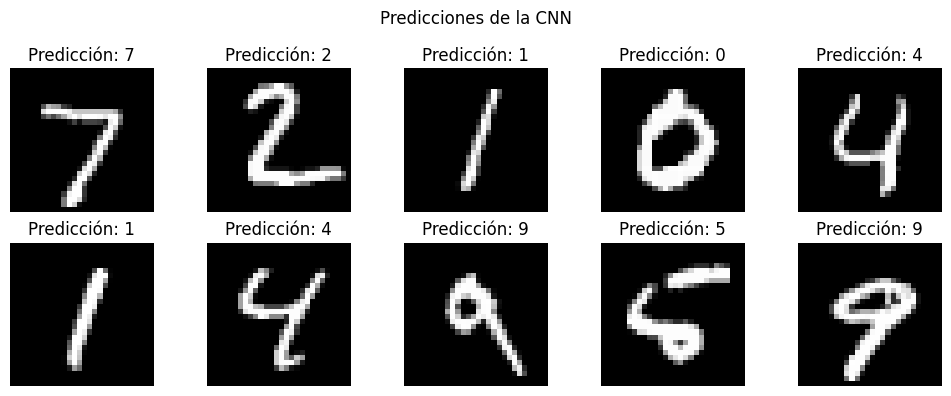

In [ ]:
# Evaluación
test_loss, test_acc = model.evaluate(X_test, y_test_cat)
print(f"Precisión en datos de prueba: {test_acc*100:.2f}%")

# Predecir algunas imágenes (las 10 primeras)
predictions = model.predict(X_test[:10])
predicted_classes = np.argmax(predictions, axis=1)

# Visualizar resultados
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_test[i].reshape(28, 28), cmap='gray')
    plt.title(f"Predicción: {predicted_classes[i]}")
    plt.axis('off')
plt.suptitle("Predicciones de la CNN")
plt.tight_layout()
plt.show()

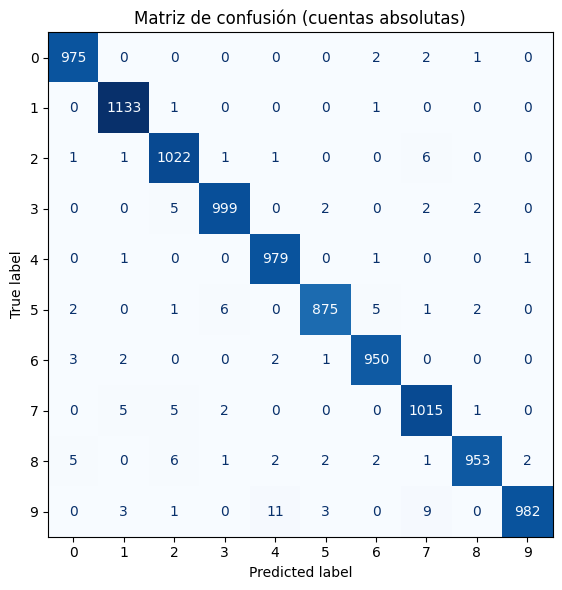


Reporte de clasificación:
              precision    recall  f1-score   support

           0     0.9888    0.9949    0.9919       980
           1     0.9895    0.9982    0.9939      1135
           2     0.9817    0.9903    0.9860      1032
           3     0.9901    0.9891    0.9896      1010
           4     0.9839    0.9969    0.9904       982
           5     0.9909    0.9809    0.9859       892
           6     0.9886    0.9916    0.9901       958
           7     0.9797    0.9874    0.9835      1028
           8     0.9937    0.9784    0.9860       974
           9     0.9970    0.9732    0.9850      1009

    accuracy                         0.9883     10000
   macro avg     0.9884    0.9881    0.9882     10000
weighted avg     0.9883    0.9883    0.9883     10000



In [ ]:
# Matriz de confusión y reporte de clasificación
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# Predicciones en TODO el conjunto de prueba
y_pred_probs = model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = y_test  # ya es entero 0-9

# Matriz de confusión (cuentas)
cm = confusion_matrix(y_true, y_pred, labels=np.arange(10))

# Opción 1: visualizar cuentas absolutas
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.arange(10))
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)
plt.title("Matriz de confusión (cuentas absolutas)")
plt.tight_layout()
plt.show()


# Reporte de clasificación (precisión, recall, f1 por clase)
print("\nReporte de clasificación:")
print(classification_report(y_true, y_pred, digits=4))
